# Random Walk & Markov Chains (Lab 8)

## Import & Support Data

In [1]:
! pip install networkx scikit-learn tabulate pandas numpy matplotlib  -q

In [2]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

from typing import List

rng = np.random.default_rng(96)

## Support Functions

In [7]:
def mfpt_teorico(G, target):
    nodes = list(G.nodes())
    n = len(nodes)
    idx = {node: i for i, node in enumerate(nodes)}
    j = idx[target]
    
    # 1. Matriz de adjacência e graus
    A = nx.to_numpy_array(G, nodelist=nodes)
    k = A.sum(axis=1)
    
    # 2. Matriz de transição P_ij = A_ij / k_i
    P = A / k[:, None]
    
    # 3. Remove linha e coluna do alvo
    mask = np.ones(n, dtype=bool)
    mask[j] = False
    P_sub = P[np.ix_(mask, mask)]
    
    # 4. Resolve (I - P_sub) T = 1
    I = np.eye(n - 1)
    ones = np.ones(n - 1)
    T_sub = np.linalg.solve(I - P_sub, ones)
    
    # 5. Reconstrói vetor completo com T[target] = 0
    T = np.zeros(n)
    T[mask] = T_sub
    
    return {nodes[i]: T[i] for i in range(n)}

In [8]:
def random_walk_a_to_b(G: nx.Graph, initial, target)-> tuple[List, int]: 
    if initial == target:
        return [], 0
    
    current = initial

    max_steps = len(G) * 100_000

    nodes = []
    nodes.append(current)

    for step in range(1, max_steps+1):
        neighbors = list(G.neighbors(current))
        current = neighbors[rng.integers(0, len(neighbors))]
        nodes.append(current)

        if current == target:
            return nodes, step

    return nodes, -1 # -1 mean reached max step size without reaching the target 

In [9]:
sqrt_err = lambda simulated, teoric: ((abs(simulated - teoric) / teoric )* 100).item()

In [10]:
def mean_simulation_mfpt(G, initial, target):
    num_simulations = 50_000
    res = []
    for i in range(num_simulations):
        _, total = random_walk_a_to_b(G, initial, target)
        res.append(total)

    mean_value = np.mean(np.array(res))
    return mean_value.item()

## Tempo Médio de Primeira Passagem (MFPT)

In [10]:
G = nx.cycle_graph(6)
initial, target = random.sample(list(G.nodes()), 2)

print(initial, target)

4 0


In [11]:
num_simulations = 100_000
res = []
for i in range(num_simulations):
    _, total = random_walk_a_to_b(G, initial, target)
    res.append(total)

mean_value = np.mean(np.array(res))
print(mean_value)

7.97708


In [12]:
mfpt_teorico(G, target)[initial].item()

8.0

In [16]:
G = nx.erdos_renyi_graph(20, 0.5)

In [21]:
num_simulations = 100_000
initial, target = random.sample(list(G.nodes()), 2)
res = []
for i in range(num_simulations):
    _, total = random_walk_a_to_b(G, initial, target)
    res.append(total)

mean_value = np.mean(np.array(res))
print(f"ER Mean T for initial={initial} and target={target} ==> {mean_value:.2f}")

ER Mean T for initial=15 and target=16 ==> 17.63


In [26]:
teoric = mfpt_teorico(G, target)[initial].item()
print(f"{mfpt_teorico(G, target)[initial].item():.2f}")

17.59


In [29]:
sqrt_err(mean_value, teoric)

0.23716850201827727

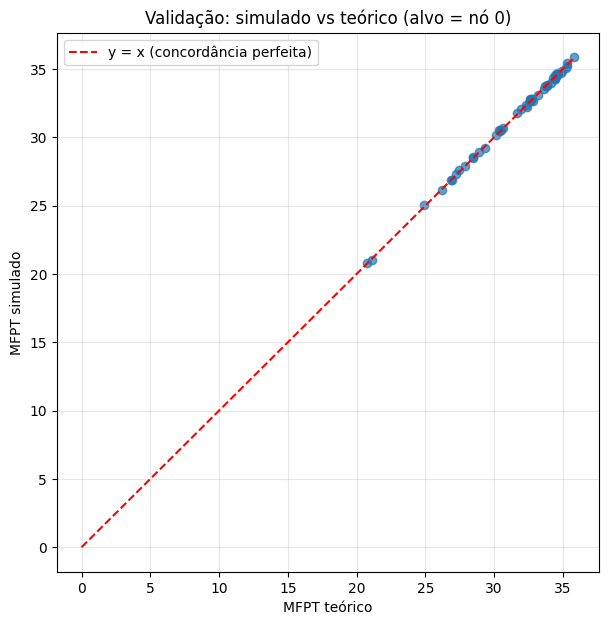

In [ ]:
target = random.sample(list(G.nodes()), 1)

T_teorico_dict = mfpt_teorico(G, target=target)

T_teorico_vals = []
T_simulado_vals = []

for initial in G.nodes():
    if initial == target:
        continue
    
    n_sim = 50_000 
    tempos = []
    for _ in range(n_sim):
        _, t = random_walk_a_to_b(G, initial, target)
        if t > 0:
            tempos.append(t)
    
    T_teorico_vals.append(T_teorico_dict[initial])
    T_simulado_vals.append(np.mean(tempos))

T_teorico_vals = np.array(T_teorico_vals)
T_simulado_vals = np.array(T_simulado_vals)

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(T_teorico_vals, T_simulado_vals, alpha=0.7)
max_val = max(T_teorico_vals.max(), T_simulado_vals.max())
min_val = min(T_teorico_vals.min(), T_simulado_vals.min())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (concordância perfeita)')


plt.xlabel('MFPT teórico')
plt.ylabel('MFPT simulado')
plt.legend()
plt.grid(alpha=0.3)
plt.title(f'Validação: simulado vs teórico (alvo = nó {target})')
plt.show()

In [76]:
errors = []
for i in range(len(T_teorico_vals)):
    error = (abs(T_simulado_vals[i] - T_teorico_vals[i]) / T_teorico_vals[i] )* 100
    errors.append(error)

mean_square_error = np.mean(np.array(errors)).item()
print(f"Mean Square Error: {mean_square_error:.2f} %")

0.2664061241116267

## Tempo Médio de Primeira Passagem (MFPT) vs Shortest Path

In [44]:
G = nx.erdos_renyi_graph(500, 0.02)
G_1 = nx.erdos_renyi_graph(50, 0.1)
G_2 = nx.cycle_graph(6)
G_3 = nx.barabasi_albert_graph(n=100, m=3)

In [45]:
def run_simulation_mfpt_vs_shortest_path(G):    
    nodes = list(G.nodes())
    N = len(nodes)

    # Calcula MFPT 
    T_matrix = np.zeros((N, N))
    for j in nodes:
        T_dict = mfpt_teorico(G, target=j)
        for i in nodes:
            T_matrix[i, j] = T_dict[i]

    # Calcula distâncias pra todos os pares: O(N + M) com BFS único
    dist = dict(nx.all_pairs_shortest_path_length(G))

    # Empilha em vetores paralelos
    dists = []
    mfpts = []
    for i in nodes:
        for j in nodes:
            if i != j:
                dists.append(dist[i][j])
                mfpts.append(T_matrix[i, j])

    dists = np.array(dists)
    mfpts = np.array(mfpts)

    return (dists, mfpts)

In [46]:
def plot_histogram(dists, mfpts):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(dists, bins=range(int(dists.min()), int(dists.max()) + 2), 
                edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Menor distância d(i, j)')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Distribuição de distâncias')
    axes[0].grid(alpha=0.3)

    axes[1].hist(mfpts, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('MFPT T(i, j)')
    axes[1].set_ylabel('Frequência')
    axes[1].set_title('Distribuição de MFPT')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

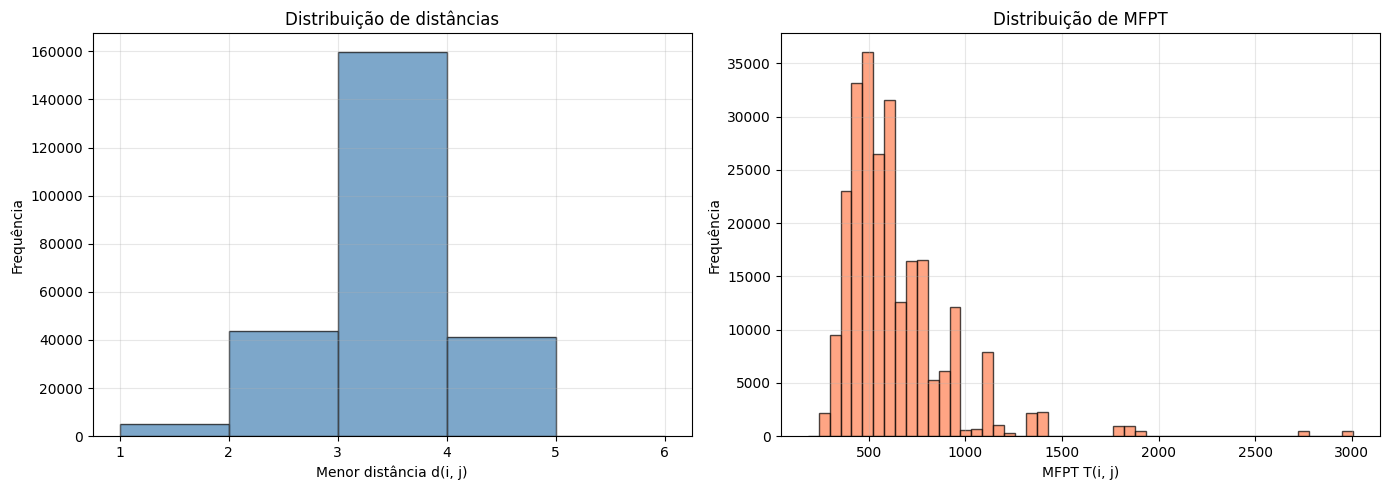

Spearman: 0.2793
Pearson:  0.2550


In [47]:
dists, mfpts = run_simulation_mfpt_vs_shortest_path(G)
plot_histogram(dists, mfpts)
rho_s, _ = spearmanr(dists, mfpts)
rho_p, _ = pearsonr(dists, mfpts)
print(f"Spearman: {rho_s:.4f}")
print(f"Pearson:  {rho_p:.4f}")

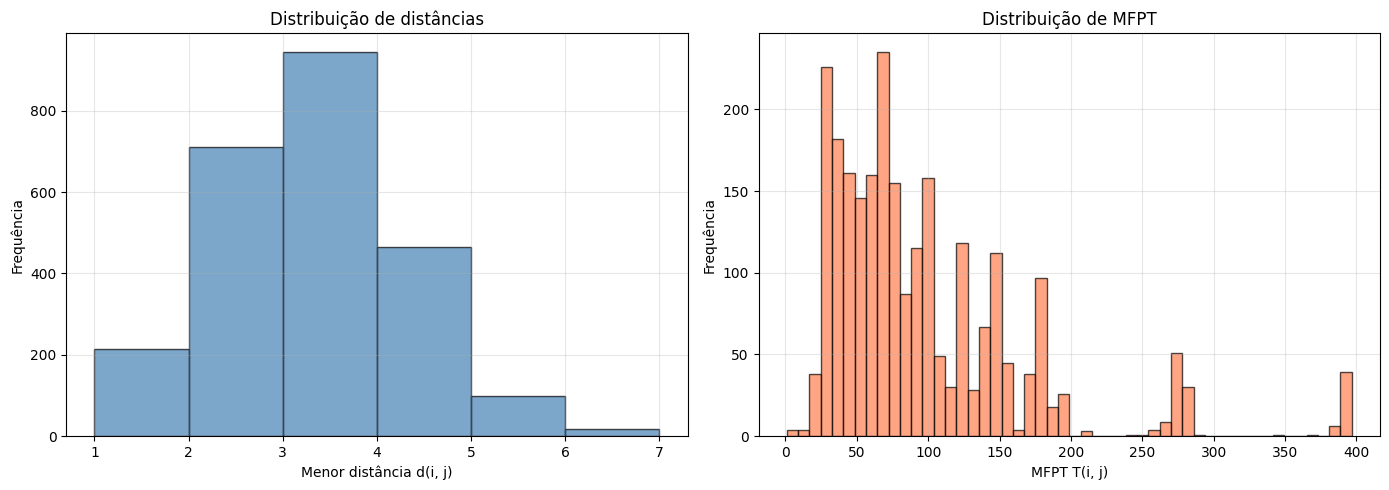

Spearman: 0.5329
Pearson:  0.5082


In [48]:
dists, mfpts = run_simulation_mfpt_vs_shortest_path(G_1)
plot_histogram(dists, mfpts)
rho_s, _ = spearmanr(dists, mfpts)
rho_p, _ = pearsonr(dists, mfpts)
print(f"Spearman: {rho_s:.4f}")
print(f"Pearson:  {rho_p:.4f}")

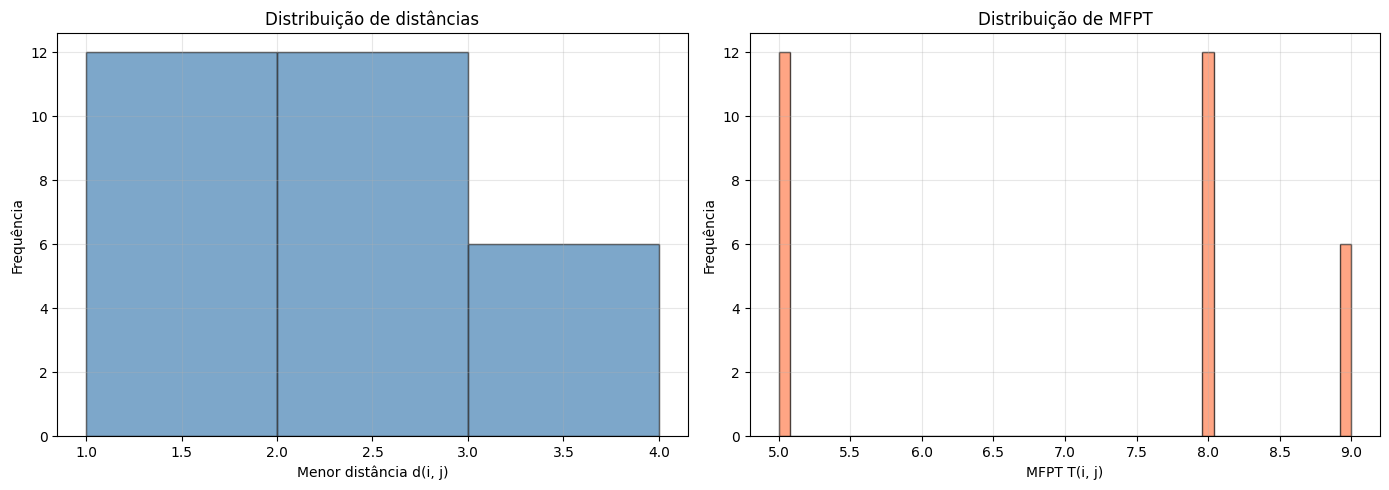

Spearman: 0.9503
Pearson:  0.9583


In [49]:
dists, mfpts = run_simulation_mfpt_vs_shortest_path(G_2)
plot_histogram(dists, mfpts)
rho_s, _ = spearmanr(dists, mfpts)
rho_p, _ = pearsonr(dists, mfpts)
print(f"Spearman: {rho_s:.4f}")
print(f"Pearson:  {rho_p:.4f}")

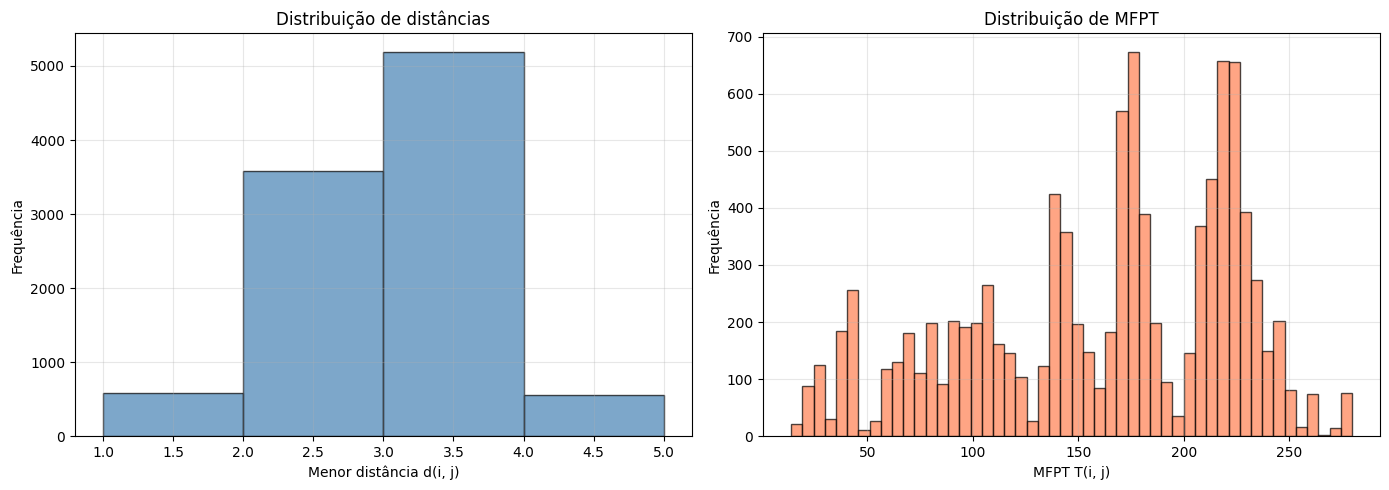

Spearman: 0.3874
Pearson:  0.3992


In [50]:
dists, mfpts = run_simulation_mfpt_vs_shortest_path(G_3)
plot_histogram(dists, mfpts)
rho_s, _ = spearmanr(dists, mfpts)
rho_p, _ = pearsonr(dists, mfpts)
print(f"Spearman: {rho_s:.4f}")
print(f"Pearson:  {rho_p:.4f}")

## Número médio de visitas a cada vértice vs Centralidade

In [11]:
G = nx.barabasi_albert_graph(n=100, m=3)

In [12]:
centralities = {
    "degree":       dict(G.degree()),
    "betweenness":  nx.betweenness_centrality(G),
    "closeness":    nx.closeness_centrality(G),
    "eigenvector":  nx.eigenvector_centrality_numpy(G),
    "pageRank":     nx.pagerank(G, alpha=0.85),
    "k-core":       nx.core_number(G),
}


In [13]:
from collections import Counter
def visit_counts(G, source, n_steps=500_000):
    nbrs_cache = {v: list(G.neighbors(v)) for v in G.nodes()}
    counts = Counter()
    current = source
    counts[current] += 1
    for _ in range(n_steps):
        nbrs = nbrs_cache[current]
        current = nbrs[rng.integers(0, len(nbrs))]
        counts[current] += 1
    return counts

counts = visit_counts(G, source=0, n_steps=500_000)
visits = np.array([counts.get(v, 0) for v in G.nodes()])

# 3. Sanity check: visitas devem ser proporcionais ao grau
visits_freq = visits / visits.sum()
m = G.number_of_edges()
pi_theo = np.array([G.degree(v) / (2 * m) for v in G.nodes()])

rho_sanity, _ = spearmanr(visits_freq, pi_theo)
print(f"Sanity check — visitas vs π_v = k_v/(2m): Spearman = {rho_sanity:.4f}")
print(f"Erro L1 = {np.abs(visits_freq - pi_theo).sum():.4f}")

Sanity check — visitas vs π_v = k_v/(2m): Spearman = 0.9717
Erro L1 = 0.0114


In [14]:
for name, c_dict in centralities.items():
    c_arr = np.array([c_dict[v] for v in G.nodes()])
    rho, _ = spearmanr(visits, c_arr)
    print(f"{name:<15} Spearman = {rho:.4f}")

degree          Spearman = 0.9717
betweenness     Spearman = 0.9004
closeness       Spearman = 0.6930
eigenvector     Spearman = 0.6820
pageRank        Spearman = 0.9536
k-core          Spearman = nan


/tmp/ipykernel_23549/2866494876.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(visits, c_arr)
